In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from collections import Counter
from datasets import load_dataset

dataset = load_dataset("Psychotherapy-LLM/CBT-Bench", "core_fine_test")

C:\Users\Maja\projects\belief-trace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'ori_text', 'situation', 'thoughts', 'core_belief_fine_grained'],
        num_rows: 112
    })
})

In [4]:
core_beliefs = dataset["train"]["core_belief_fine_grained"]
len(core_beliefs)

112

In [5]:
core_beliefs[:5]

[['I am powerless, weak, vulnerable',
  'I am a victim',
  'I am trapped',
  'I am undesirable, unwanted',
  'I am bound to be abandoned'],
 ['I am incompetent', 'I am powerless, weak, vulnerable', 'I am a victim'],
 ['I am a victim', 'I am trapped', 'I am out of control'],
 ['I am helpless', 'I am undesirable, unwanted'],
 ['I am incompetent',
  'I am helpless',
  'I am powerless, weak, vulnerable',
  'I am bad - dangerous, toxic, evil']]

In [6]:
flat_beliefs = {
    belief
    for beliefs in core_beliefs
    for belief in beliefs
}

print(f"Number of unique beliefs: {len(flat_beliefs)}")
flat_beliefs

Number of unique beliefs: 19


{'I am a failure, loser',
 'I am a victim',
 'I am bad - dangerous, toxic, evil',
 'I am bound to be abandoned',
 'I am bound to be alone',
 'I am bound to be rejected',
 'I am defective',
 'I am helpless',
 'I am immoral',
 'I am incompetent',
 'I am needy',
 'I am out of control',
 'I am powerless, weak, vulnerable',
 'I am trapped',
 'I am unattractive',
 'I am undesirable, unwanted',
 'I am unlovable',
 'I am worthless, waste',
 'I don’t deserve to live'}

In [7]:
belief_dict = Counter(
    belief
    for beliefs in core_beliefs
    for belief in beliefs
)

belief_dict

Counter({'I am powerless, weak, vulnerable': 38,
         'I am helpless': 36,
         'I am defective': 31,
         'I am worthless, waste': 31,
         'I am a victim': 29,
         'I am bound to be rejected': 29,
         'I am trapped': 28,
         'I am undesirable, unwanted': 27,
         'I am unlovable': 25,
         'I am bound to be abandoned': 24,
         'I am out of control': 22,
         'I am a failure, loser': 22,
         'I am bound to be alone': 21,
         'I am incompetent': 16,
         'I am bad - dangerous, toxic, evil': 14,
         'I am immoral': 10,
         'I don’t deserve to live': 8,
         'I am unattractive': 6,
         'I am needy': 5})

In [8]:
import pandas as pd

df = pd.DataFrame(
    belief_dict.items(),
    columns=["belief", "count"]
)

df.sort_values("count")

,belief,count
16,I am needy,5
18,I am unattractive,6
15,I don’t deserve to live,8
12,I am immoral,10
8,"I am bad - dangerous, toxic, evil",14
5,I am incompetent,16
17,I am bound to be alone,21
14,"I am a failure, loser",22
6,I am out of control,22
4,I am bound to be abandoned,24


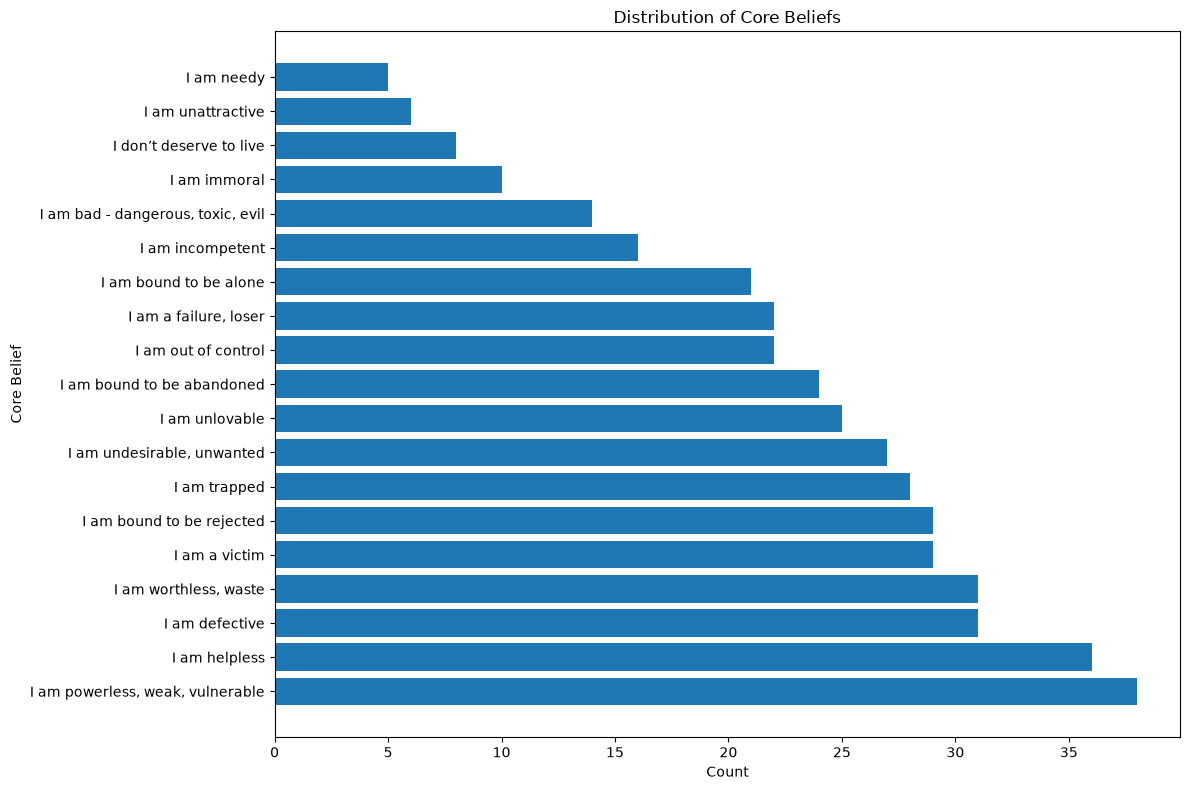

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    belief_dict.items(),
    columns=["belief", "count"]
).sort_values("count", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(df["belief"], df["count"])
plt.xlabel("Count")
plt.ylabel("Core Belief")
plt.title("Distribution of Core Beliefs")
plt.tight_layout()
plt.show()

In [10]:
from transformers import AutoTokenizer

# Load the tokenizer for Llama 3.1 8B
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")

def calculate_tokens(text):
    """Calculates the number of tokens for a given text using the Llama 3.1 8B tokenizer."""
    return len(tokenizer.encode(text, add_special_tokens=True))

# Apply the function to the 'ori_text' field in the training dataset
dataset["train"] = dataset["train"].map(lambda x: {"num_tokens": calculate_tokens(x["ori_text"])})

# Display the token counts
print(dataset["train"]["num_tokens"][:10])
print(f"Average number of tokens: {sum(dataset['train']['num_tokens']) / len(dataset['train'])}")
print(f"Max number of tokens: {max(dataset['train']['num_tokens'])}")  # Max number of tokens: 888

Map: 100%|██████████| 112/112 [00:00<00:00, 1643.82 examples/s]

[69, 94, 65, 117, 144, 321, 97, 112, 444, 614]
Average number of tokens: 215.10714285714286
Max number of tokens: 888
